<a href="https://colab.research.google.com/github/Fabian-lewis/remote-work-productivity-analysis/blob/main/02_hypothesis_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
## Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [15]:
## Load Data From Colab
from google.colab import drive

drive.mount('/content/drive')

data_url = "/content/drive/MyDrive/RemoteWork"

## Load Cleaned data
try:
  df_2020 = pd.read_csv(f"{data_url}/cleaned_data_2020.csv")
  df_2021 = pd.read_csv(f"{data_url}/cleaned_data_2021.csv")

  print(f"2020 Data Loaded ✅ {df_2020.shape}")
  print(f"2021 Data Loaded ✅ {df_2021.shape}")

except Exception as e:
  print("Error Loading Data")
  print(e)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
2020 Data Loaded ✅ (1507, 74)
2021 Data Loaded ✅ (1507, 74)


/tmp/ipython-input-2259263033.py:68: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("remote_intensity_group")["remote_productivity_vs_office"]
/tmp/ipython-input-2259263033.py:68: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("remote_intensity_group")["remote_productivity_vs_office"]


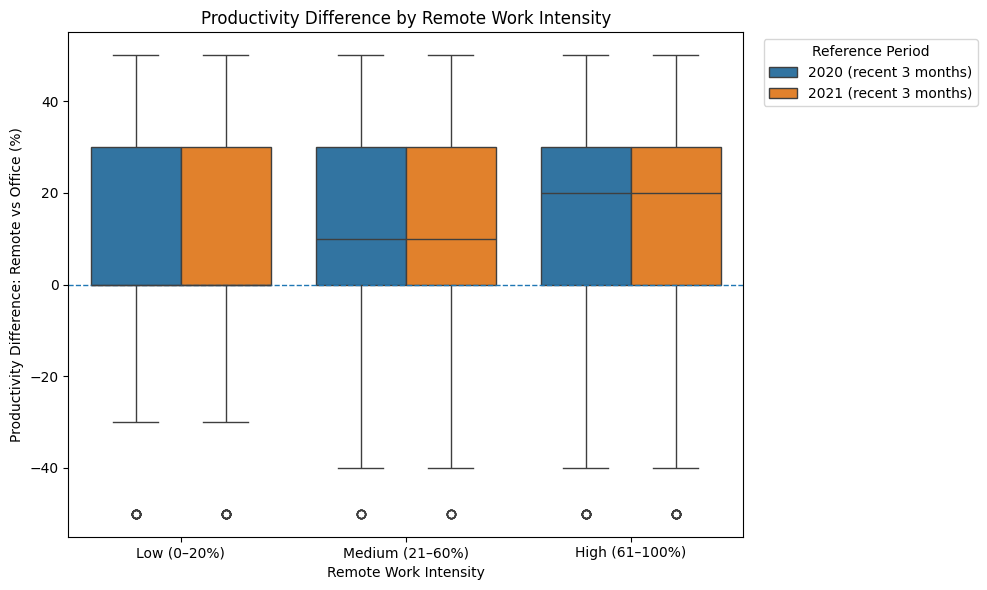

Group Summary 2020:

 --------------------------------------------------------------------------------
  remote_intensity_group  count       mean  median        std
0            Low (0–20%)    282   8.262411     0.0  24.973194
1        Medium (21–60%)    357  10.672269    10.0  23.716411
2         High (61–100%)    868  15.541475    20.0  23.269285

Group Summary 2021:

 --------------------------------------------------------------------------------
  remote_intensity_group  count       mean  median        std
0            Low (0–20%)    282   8.262411     0.0  24.973194
1        Medium (21–60%)    357  10.672269    10.0  23.716411
2         High (61–100%)    868  15.541475    20.0  23.269285



Hypothesis 1: Productivity Difference by Remote Work Intensity
2020 vs 2021
KruskalResult(statistic=np.float64(23.686480496083377), pvalue=np.float64(7.18697464025728e-06))


KruskalResult(statistic=np.float64(23.686480496083377), pvalue=np.float64(7.18697464025728e-06))


/tmp/ipython-input-2259263033.py:113: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, g in df.groupby("remote_intensity_group")


In [20]:
## Hypothesis 1
"""
H1 — Remote work intensity and productivity
H1: Employee productivity differs across levels of remote work intensity.

We are measuring:
Self-reported percentage difference in hourly productivity when remote vs on-site


Proxy variable:
remote_productivity_vs_office

caution ⚠️
This is:
Subjective
Comparative (remote vs office)
Perceived, not observed

"""

## Create remote intensity categories
def categorize_remote_share(series, scale="percent"):
    """
    Categorize remote work intensity into Low / Medium / High.

    Parameters:
    - series: pandas Series of remote share values
    - scale: 'percent' (0–100) or 'proportion' (0–1)

    Returns:
    - pandas Series of categorical labels
    """
    s = series.copy()

    if scale == "percent":
        s = s / 100

    return pd.cut(
        s,
        bins=[-np.inf, 0.20, 0.60, np.inf],
        labels=["Low (0–20%)", "Medium (21–60%)", "High (61–100%)"]
    )


## Apply to both datasets
df_2020["remote_intensity_group"] = categorize_remote_share(
    df_2020['remote_share_recent_actual'],
    scale="proportion"
)

df_2021["remote_intensity_group"] = categorize_remote_share(
    df_2021['remote_share_recent_actual'],
    scale="proportion"
)

## Keep only valid observations
analysis_df_2020 = df_2020.dropna(
    subset=['remote_productivity_vs_office', 'remote_intensity_group']
)

analysis_df_2021 = df_2021.dropna(
    subset=['remote_productivity_vs_office', 'remote_intensity_group']
)

## Exploratory group summary
def summarize_productivity(df):
    return (
        df.groupby("remote_intensity_group")["remote_productivity_vs_office"]
        .agg(count="count", mean="mean", median="median", std="std")
        .reset_index()
    )

group_summary_2020 = summarize_productivity(analysis_df_2020)
group_summary_2021 = summarize_productivity(analysis_df_2021)


## Visualize the results
combined_df = pd.concat([
    analysis_df_2020.assign(period="2020 (recent 3 months)"),
    analysis_df_2021.assign(period="2021 (recent 3 months)")
])

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=combined_df,
    x="remote_intensity_group",
    y="remote_productivity_vs_office",
    hue="period"
)

plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Productivity Difference by Remote Work Intensity")
plt.xlabel("Remote Work Intensity")
plt.ylabel("Productivity Difference: Remote vs Office (%)")

plt.legend(
    title="Reference Period",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


## Hypothesis test (inference layer)
from scipy.stats import kruskal

def run_kruskal(df):
  groups = [
      g["remote_productivity_vs_office"].values
      for _, g in df.groupby("remote_intensity_group")
  ]
  return kruskal(*groups)

kruskal_result_2020 = run_kruskal(analysis_df_2020)
kruskal_result_2021 = run_kruskal(analysis_df_2021)

## Print the group summaries
print("Group Summary 2020:")
print("\n","-"*80)
print(group_summary_2020)

print("\nGroup Summary 2021:")
print("\n","-"*80)
print(group_summary_2021)

## Print the results
print("\n"*2)
print("="*80)
print("Hypothesis 1: Productivity Difference by Remote Work Intensity")
print("="*80)
print("2020 vs 2021")
print(kruskal_result_2020)
print("\n")
print(kruskal_result_2021)


### Summary Insight
---

    Employee productivity differs significantly across levels of remote work intensity.

    Employees with low levels of remote work report no productivity advantage when working remotely, while those in hybrid arrangements report approximately a 10% productivity gain
    
    Employees who are predominantly remote report the highest productivity gains, at approximately 20% relative to on-site work.

#### Evidence

1.   Statistical significance

    p ≈ 0.000007

    Kruskal–Wallis result (p < 0.001)

2.   Directional consistency

    In both survey periods,
    employees with medium to high remote intensity
    report higher median productivity compared to low-remote employees

  | Remote Intensity | Median Productivity Difference |
  | ---------------- | ------------------------------ |
  | Low (0–20%)      | **0%**                         |
  | Medium (21–60%)  | **+10%**                       |
  | High (61–100%)   | **+20%**                       |



---

#### ** Key Take-Away
1. High-remote workers may:

    - Have roles more suitable for remote work
    - Be more autonomous
    - Be more experienced

2. Median for low intensity = 0% (Not negative)

    This suggests:
    - Remote work is not harmful even at low intensity
    - But benefits only materialize with sufficient exposure